##### Chat bot with Multiple Tools
https://docs.langchain.com/oss/python/integrations/tools
- create chat bot with tool capablities from tavily(web search), Arxiv, wikipedia search and some custom functions

In [4]:
## arxiv tool
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper, WikipediaAPIWrapper

In [5]:
api_wrapper_arxiv = ArxivAPIWrapper(top_k_results=2, doc_content_chars_max=500)
arxiv = ArxivQueryRun(api_wrapper=api_wrapper_arxiv)
arxiv.name

'arxiv'

In [6]:
arxiv.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifi'

In [7]:
## Wikipedia tool
api_wrapper_wiki = WikipediaAPIWrapper(top_k_results=2, doc_content_chars_max=500)
wiki = WikipediaQueryRun(api_wrapper=api_wrapper_wiki)
wiki.name


'wikipedia'

In [8]:
wiki.invoke("HUNTER X HUNTER")

'Page: Hunter × Hunter\nSummary: Hunter × Hunter (pronounced "hunter hunter") is a Japanese manga series written and illustrated by Yoshihiro Togashi. It has been serialized in Shueisha\'s shōnen manga magazine Weekly Shōnen Jump since March 1998, although the manga has frequently gone on extended hiatuses since 2006. Its chapters have been collected in 38 tankōbon volumes as of September 2024. The story focuses on a young boy named Gon Freecss who discovers that his father, who left him at a young'

In [9]:
# custom tools


def add(a: int, b: int) -> int:
    """Add a and b
    Args:
        a(int): first int
        b(int): second int

        returns:
        int
    """
    return a + b


def multiply(a: int, b: int) -> int:
    """Multiply a and b
    Args:
       a(int): first int
       b(int): second int

       returns:
       int
    """
    return a * b


def divide(a: int, b: int) -> int:
    """Multiply a and b
    Args:
      a(int): first int
      b(int): second int

      returns:
      int
    """
    return a / b

In [10]:
## Tavily
import os
from dotenv import load_dotenv

load_dotenv()

os.environ["GROQ_API_KEY"] = os.environ.get("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"] = os.environ.get("TAVILY_API_KEY")
os.environ["LANGCHAIN_API_KEY"] = os.environ.get("LANGCHAIN_API_KEY")
os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_PROJECT_NAME"] = os.environ.get("LANGCHAIN_PROJECT_NAME")

In [12]:
"""
from langchain_tavily import TavilySearch

tavily = TavilySearch(
    max_results=5,
    topic="general",
)
"""

from langchain_community.tools.tavily_search import TavilySearchResults
tavily = TavilySearchResults()

In [13]:
tavily.invoke({"query": "What are the IPL standings in 2026"})

[{'title': 'Indian Premier League Standings - 2026 - ESPN',
  'url': 'https://www.espn.com/cricket/standings/series/8048/ipl',
  'content': "| 9Lucknow Super GiantsLSG | 7 | 2 | 5 | 0 | 0 | 4 | -1.277 | 1112/139.5 | 1209/131.0 |\n| 10Kolkata Knight RidersKKR | 7 | 1 | 5 | 0 | 1 | 3 | -0.879 | 1063/119.4 | 1160/118.5 | [...] | Team | M | W | L | T | N/R | PT | NRR | FOR | Against |\n ---  ---  ---  ---  --- |\n| 1Punjab KingsPBKS | 6 | 5 | 0 | 0 | 1 | 11 | 1.42 | 1050/93.1 | 985/100.0 |\n| 2Royal Challengers BengaluruRCB | 7 | 5 | 2 | 0 | 0 | 10 | 1.101 | 1424/129.4 | 1362/137.5 |\n| 3Rajasthan RoyalsRR | 7 | 5 | 2 | 0 | 0 | 10 | 0.79 | 1163/121.1 | 1151/130.4 |\n| 4Sunrisers HyderabadSRH | 7 | 4 | 3 | 0 | 0 | 8 | 0.82 | 1454/140.0 | 1285/134.2 |\n| 5Chennai Super KingsCSK | 7 | 3 | 4 | 0 | 0 | 6 | 0.118 | 1338/140.0 | 1235/130.5 |\n| 6Delhi CapitalsDC | 6 | 3 | 3 | 0 | 0 | 6 | -0.13 | 1081/115.1 | 1142/120.0 |\n| 7Gujarat TitansGT | 7 | 3 | 4 | 0 | 0 | 6 | -0.79 | 1227/138.2 | 1333/138

In [14]:
tools = [arxiv, wiki, tavily, add, multiply, divide]

In [15]:
# bind llm with tools
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")

llm_with_tools = llm.bind_tools(tools)

In [16]:
from langchain_core.messages import AIMessage, HumanMessage

tool_call = llm_with_tools.invoke(
    [HumanMessage(content=f"what is the recent IPL news")]
)
tool_call

AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for recent IPL news. IPL is the Indian Premier League, a cricket tournament. To get the latest news, I should use a search tool that can fetch current information. Looking at the available tools, there\'s \'tavily_search_results_json\' which is optimized for current events. The other tools like arxiv and wikipedia are for academic papers and general knowledge, which might not have the latest updates. The user probably wants recent matches, results, or upcoming events. So I\'ll use the tavily_search_results_json function with the query "recent IPL news" to get the most up-to-date information.\n', 'tool_calls': [{'id': 'ssgvwzw25', 'function': {'arguments': '{"query":"recent IPL news"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 158, 'prompt_tokens': 663, 'total_tokens': 821, 'completion_time': 0.289753541, 'completion_tokens_

In [17]:
# checking the tool response

tool_call.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'recent IPL news'},
  'id': 'ssgvwzw25',
  'type': 'tool_call'}]

#### Create entire chatbot with the help of langgraph

In [18]:
# create schema

from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from typing import Annotated


class State(TypedDict):
    messages: Annotated[list[AnyMessage], add_messages]

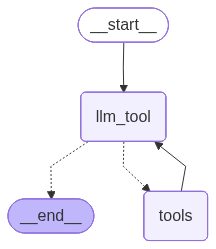

In [19]:
# configure the graph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


# creating a chatbot node
def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # if the latest message from LLM is a toolcall -> tools_condition route to tools
    # if the latest message from LLM is not a toolcall -> tools_condition route to END
    tools_condition,
)
builder.add_edge("tools", "llm_tool")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
# invoking tool without memory...
messages = graph.invoke({"messages": HumanMessage(content="What is 2 plus 8")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 2 plus 8
================================== Ai Message ==================================
Tool Calls:
  add (tnrxrjbhd)
 Call ID: tnrxrjbhd
  Args:
    a: 2
    b: 8
================================= Tool Message =================================
Name: add

10
================================== Ai Message ==================================

The result is **10**.


In [21]:
messages = graph.invoke({"messages": HumanMessage(content="Divide that by 5")})

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

Divide that by 5
================================== Ai Message ==================================

To perform the division, I need to know the specific number you want divided by 5. Could you clarify what value "that" refers to? For example, if you meant dividing 20 by 5, I would use the `divide` function with `a=20` and `b=5`. Please provide the number you'd like divided by 5.


##### Memory Saver
	1. Langgraph can use a checkpointer to automatically save the graph state after each step. 
	   All we need to do is compile the graph with a checkpointer and our graph has memory.
    2. The particular checkpointer can be accessed using threads.

https://reference.langchain.com/python/langgraph.checkpoint/memory/InMemorySaver


In [22]:
# configure the graph
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition


# creating a chatbot node
def llm_tool(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(State)

builder.add_node("llm_tool", llm_tool)
builder.add_node("tools", ToolNode(tools))

builder.add_edge(START, "llm_tool")
builder.add_conditional_edges(
    "llm_tool",
    # if the latest message from LLM is a toolcall -> tools_condition route to tools
    # if the latest message from LLM is not a toolcall -> tools_condition route to END
    tools_condition,
)
builder.add_edge("tools", "llm_tool")

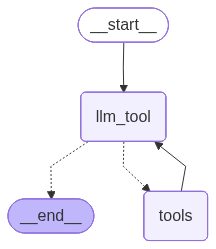

In [23]:
# compile graph with In-Memory saver...

from langgraph.checkpoint.memory import InMemorySaver
memory = InMemorySaver()
graph_memory = builder.compile(checkpointer=memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))

In [25]:
## specify the thread
config = {"configurable": {"thread_id": "1"}}
messages = graph_memory.invoke({"messages": HumanMessage(content="What is 5 plus 5")}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 5 plus 5
================================== Ai Message ==================================
Tool Calls:
  add (ynwnhpswd)
 Call ID: ynwnhpswd
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: add

10
================================== Ai Message ==================================

The result of 5 plus 5 is **10**.


In [26]:
messages = graph_memory.invoke({"messages": HumanMessage(content="divide that by 5")}, config=config)

for message in messages["messages"]:
    message.pretty_print()

================================ Human Message =================================

What is 5 plus 5
================================== Ai Message ==================================
Tool Calls:
  add (ynwnhpswd)
 Call ID: ynwnhpswd
  Args:
    a: 5
    b: 5
================================= Tool Message =================================
Name: add

10
================================== Ai Message ==================================

The result of 5 plus 5 is **10**.
================================ Human Message =================================

divide that by 5
================================== Ai Message ==================================
Tool Calls:
  divide (sfd8e1sgw)
 Call ID: sfd8e1sgw
  Args:
    a: 10
    b: 5
================================= Tool Message =================================
Name: divide

2.0
================================== Ai Message ==================================

The result of dividing 10 by 5 is **2**.
